# Seasonal AutoRegressive Integrated Moving Average (SARIMA) model


## Prerequisites:

To start the SARIMA model, you must have proper understanding of following basic concepts:

- Time Series data  
- Auto-regressive (AR) model
- Moving Average (MA) model
- Auto-regressive Moving Average (ARMA) model
- Auto-regressive Integrated Moving Average (ARIMA) model


## Learning Objective:

- Understand the concept of the SARIMA model and its mathematical notation. 

- Analyze PACF, ACF plots for different ARIMA$(p, d, q) \times (P, D, Q)_s$ model.

- Apply ARIMA$(p, d, q) \times (P, D, Q)_s$ model on Air Passengers time series data using `statsmodels`.


## Introduction to SARIMA Model

The ARIMA model can handle data with trends. However, it cannot deal with data with seasonality. We can observe seasonality in economic data like sales, revenues, etc. For example, sales of warm clothes are high in winter and less in summer and the distribution of sales over a year seems to be recurring every year. We can observe a strong dependence on the past values at multiples of some seasonal lag on such seasonal data. In a monthly sales data of warm clothes, we can observe strong dependence at lags multiples of 12, whereas, for quarterly sales data, the dependence is at lags multiples of 4. Natural phenomena like temperature, rainfall, etc. also follow strong seasonal patterns, matching with the seasonal changes. Thus using this concept, we can formulate a seasonal model where the dependence is shown on lags multiple of some season $s$. This gives rise to the SARIMA model family. We'll learn about the mathematical formulation for a pure SARIMA model with seasonal components only in 1.1.1. And we'll learn the mathematical definition for the multiplicative SARIMA model with seasonal and non-seasonal components in 1.1.2. 


### Mathematical Expressions 



#### Pure SARIMA$(P, D, Q)_s$ Model

>$X_t$ is said to be generated by a pure SARIMA$(P, D, Q)_s$ model if
$$
\begin{align*}
\Phi_P(B^s) \nabla_s ^D X_t &= \Theta_Q(B^s) Z_t
\end{align*}
$$

where,

* $s$ is the season for the model.

* $\Phi_P(B^s)$ and $\Theta_Q(B^s)$ are seasonal AR and  MA components of orders $P$ and $Q$, respectively.

* $\nabla _s = 1 - B^s$ is the seasonal difference operator.
    * $\nabla _s X_t = (1- B^s) X_t = X_t - X_{t - s}$ 





The model, defined in section 1.1.1., is a pure seasonal model. The dependence on the past is only on lags that are multiples of some season $s$. However, there can be some form of dependence on immediate past values also, not only from the values from a season ago. This brings in the concept of the multiplicative SARIMA model. It is a multiplicative mixture of pure seasonal and non-seasonal models. This mixture enables both seasonal and non-seasonal dependences, which we'll analyze by plotting ACF and PACF graphs for different models in this chapter. We'll define this model next.


#### ARIMA$(p, d, q) \times (P, D, Q)_s$ Model

> $X_t$ is said to be generated by an ARIMA$(p, d, q) \times (P, D, Q)_s$ model if

$$
\begin{align*}
\Phi_P(B^s) \phi_p(B) \nabla_s ^D \nabla ^d X_t &= \Theta_Q(B^s) \theta_q(B) Z_t
\end{align*}
$$


where,

* $\phi_p(B)$ and $\theta_q(B)$ are ordinary AR and MA components of orders $p$ and $q$ respectively.

* $s$ is the season for the model.

* $\Phi_P(B^s)$ and $\Theta_Q(B^s)$ are seasonal AR and MA components of orders $P$ and $Q$ respectively.

* $\nabla _s = 1 - B^s$ is the seasonal difference operator.
    * $\nabla _s X_t = (1- B^s) X_t = X_t - X_{t - s}$ 

* $Z_t$ is white noise introduced at current time $t$. 

\\

Whenever we mention the SARIMA model, it'll mean the mixed SARIMA model with both non-seasonal and seasonal components in the remaining portion of this chapter. So, whenever we need to mention about pure SARIMA model, we'll explicitly call it pure SARIMA model.



## Examples 

Let's see some examples of SARIMA models.



#### $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ 

$$
\begin{align*}&&
\Phi_1(B^{12}) \phi_1(B) X_t &= \Theta_1(B^{12}) \theta_1(B) Z_t
\\ \implies && (1 - \Phi B^{12}) (1 - \phi B)  X_t &= (1 + \Theta B^{12}) (1 + \theta B) Z_t
\\ \implies && (1 - \phi B - \Phi B^{12} + \Phi \phi B^{13}) X_t &= (1 + \theta B + \Theta B^{12} + \Theta \theta  B^{13}) Z_t
\\ \implies && X_t - \phi B X_t - \Phi B^{12} X_t + \Phi \phi B^{13} X_t &= Z_t + \theta B Z_t + \Theta B^{12} Z_t + \Theta \theta  B^{13} Z_t
\\ \implies && X_t - \phi X_{t-1} - \Phi X_{t-12} + \Phi \phi X_{t-13} &= Z_t + \theta Z_{t-1} + \Theta Z_{t-12} + \Theta \theta Z_{t-13}
\\ \implies && X_t &= \phi X_{t-1} + \Phi X_{t-12} - \Phi \phi X_{t-13} + Z_t + \theta Z_{t-1} + \Theta Z_{t-12} + \Theta \theta Z_{t-13}
\end{align*}
$$  




#### $\text{ARIMA}(0, 1, 1) \times (0, 1, 1)_{12}$ 

$$
\begin{align*}&&
\nabla_{12} \nabla  X_t &= \Theta_1(B^{12}) \theta_1(B) Z_t
\\ \implies &&
(1 - B^{12}) (1 - B)  X_t &= (1 + \Theta B^{12}) (1 + \theta B) Z_t
\\ \implies &&
(1 - B - B^{12} + B^{13})  X_t &= (1 + + \theta B + \Theta B^{12} + + \Theta \theta B^{13}) Z_t
\\ \implies &&
X_t  &= (B + B^{12} - B^{13})  X_t + (1 + + \theta B + \Theta B^{12} + \Theta \theta B^{13}) Z_t
\\ \implies &&
X_t  &= X_{t-1} + X_{t-12} - X_{t-13} + Z_t + \theta Z_{t-1} + \Theta Z_{t- 12} + \Theta \theta Z_{t -13}
\end{align*}
$$

Here, one can see that as the effect of using the differencing of season equal to 12. The value for $X_t$ depends not only on the values adjacent to the time stamp $t$ but also the values 12 timestamps before.    




## Synthetic Data Generation and ACF, PACF Plots

We'll use the general equation for $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ from 1.2.1 and use this to get different simpler models with different values for $\phi, \theta, \Phi, \Theta$. Let's import all the libraries required for this reading material first.



In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy import optimize
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa import stattools
from statsmodels.tsa.statespace import tools 
from statsmodels.tsa.arima_process import ArmaProcess

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


We define the `plot_series` function to plot time series data and `plot_graphs` function to plot ACF and PACF graphs for a given time series data as in previous chapters.


In [ ]:
def plot_series(X, X_=None, title='Time Series Plot', y_label='Value of X', 
                figsize=(16, 5), forecast=False, season=12):
    
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
        X_ (np.array): Forecasted time-series data
        title (str) - Title for the figure
        y_label (str) - y-label for the figure
        figsize (tuple): Size of figure
        forecast (bool): if true appends predictions after observed data
        season (int): season

    """

    fig = plt.figure(figsize=figsize)
    
    plt.plot(X, linewidth=3)

    if X_ is not None:
        if not forecast:
            plt.plot(X_, linewidth=3)
        else:
            plt.plot(range(len(X), len(X_) + len(X)), X_)

    plt.title(title, fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    
    plt.xticks(
        range(0, len(X) + 1 if not forecast else len(X) + len(X_) + 1, season), 
        fontsize=14
    ) 
    
    if X_ is not None:
        plt.legend(['True Values', 'Forecasted Values'], fontsize=14)
    plt.grid()
    plt.show()


def plot_graphs(X=None, lags=121, season=12, figsize=(10, 5)):
    """ Plots ACF and PACF graphs
        
    Args:
        X (np.array): Time-series data
        lags (int): number of lags up to which ACF and PACF plots will be shown
        season (int): season  
        figsize (tuple): size for the figure
    
    """
    
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(hspace=0.5)

    title = 'Autocorrelation Plot'
    ax1 = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, title=title, ax=ax1, lags=lags)
    plt.title(title, fontsize=14)
    plt.xticks(range(0, lags, season), fontsize=14)
    plt.grid()

    title = 'Partial Autocorrelation Plot'  
    ax2 = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, title=title,  ax=ax2, lags=lags, method='ywmle',)
    plt.title(title, fontsize=14)
    plt.xticks(range(0, lags + 1, season), fontsize=14)
    plt.grid()
    plt.show()

Next, we define three more functions:

1. `generate_samples` 
    - generates time-series data using given ar and ma parameters. 

2. `generate_samples_101_101_12` - specific to  $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ model
    - generates time-series data using given values of $\phi, \theta, \Phi, \Theta $

3. `plot_graphs_101_101_12` - specific to  $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ model
    - plots ACF and PACF graphs using given values of $\phi, \theta, \Phi, \Theta $



In [ ]:
def generate_samples(ar_params, ma_params, n_samples=10000):
    # generates samples for ARMA model based on given parameters
    ar = np.r_[1, -ar_params] 
    ma = np.r_[1, ma_params] 

    np.random.seed(999)
    X = ArmaProcess(ar, ma).generate_sample(nsample=n_samples + 2000)[2000:]  
    return X 

def generate_samples_101_101_12(phi, Phi, theta, Theta):
    """ 
    generates samples for ARIMA(1, 0, 1) x (1, 0, 1)12 model based 
    on parameters
    """
    ar_params = np.hstack([[phi], np.zeros(10), [Phi], [-Phi * phi]]) 
    ma_params = np.hstack([[theta], np.zeros(10), [Theta], [Theta * theta]]) 
    X = generate_samples(ar_params, ma_params)
    return X

def plot_graphs_101_101_12(phi, Phi, theta, Theta):
    """
    generates PACF and ACF plots ARIMA(1, 0, 1) x (1, 0, 1)12 model 
    based on parameters
    """
    X = generate_samples_101_101_12(phi, Phi, theta, Theta)
    plot_graphs(X, lags=60) # figsize=(16, 5))

### Time Series Plot

Let's generate a time series data from pure seasonal $AR(1)_{12}$ using `generate_samples_101_101_12` function. The $AR(1)_{12}$ model is obtained by setting: $\phi=0, \theta=0, \Phi=0.93, \Theta=0$ in the general equation of  $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ model. Let's observe the first 49 data points in the generated time-series data.


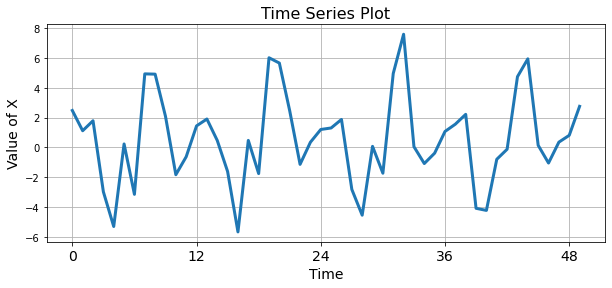

In [ ]:
X = generate_samples_101_101_12(phi=0, theta=0, Phi=0.93, Theta=0)
plot_series(X[:50], figsize=(10,4))

#### Observation

The pattern seems to be repeated after every 12 timestamps. Thus, we can observe a seasonal pattern of seasonal length 12 in the data. 


### ACF and PACF Graphs 

As before, we can the general equation for $\text{ARIMA}(1, 0, 1) \times (1, 0, 1)_{12}$ from 1.2.1 and use this to get different simpler models with different values for $\phi, \theta, \Phi, \Theta$. We'll observe following 6 different cases:


>$
\begin{align*}
1. \ \text{ARIMA} (0, 0, 0) ✕ (1, 0, 0)_{12}  : & && \phi = 0, && \theta = 0, && \Phi = 0.7, && \Theta = 0
\\
2. \ \text{ARIMA} (0, 0, 0) ✕ (0, 0, 1)_{12}  : & && \phi = 0, && \theta = 0, && \Phi = 0, && \Theta = 0.6
\\
3. \ \text{ARIMA} (0, 0, 0) ✕ (1, 0, 1)_{12}  : & && \phi = 0, && \theta = 0, && \Phi = 0.7, && \Theta = 0.6
\\
5. \ \text{ARIMA} (1, 0, 0) ✕ (1, 0, 0)_{12}  : & && \phi = 0.3, &&\theta = 0 , && \Phi = 0.7, && \Theta = 0
\\
6. \ \text{ARIMA} (0, 0, 1) ✕ (0, 0, 1)_{12}  : & && \phi = 0, && \theta =0.5, && \Phi = 0, && \Theta = 0.6
\\
4. \ \text{ARIMA} (1, 0, 1) ✕ (1, 0, 1)_{12}  : & && \phi = 0.2, && \theta =0.3, && \Phi = 0.7, && \Theta = 0.6 
\end{align*} 
$

The first example is $\text{ARIMA} (0, 0, 0) ✕ (1, 0, 1)_{12}$ which is equal to a pure seasonal $\text{AR}(1)_{12}$ model. The second example is equal to a pure seasonal $\text{MA}(1)_{12}$. Similarly, we can equate remaining models to simpler notations. Next, we'll observe the ACF and PACF plots for these six models.




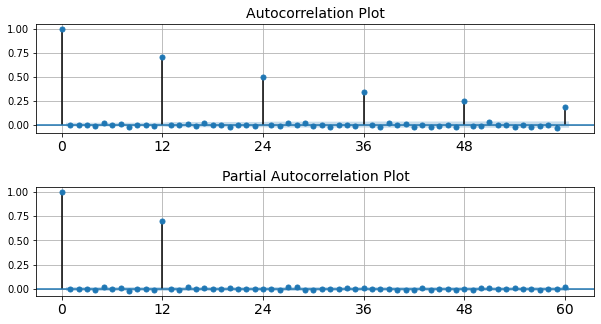

In [ ]:
plot_graphs_101_101_12(phi=0, theta=0, Phi=0.7, Theta=0)

These above graphs are for a pure seasonal $\text{AR}(1)_{12}$ model. The graphs tend to follow the pattern in ordinary AR(p) model that ACF values tend to tail off whereas PACF values cut off after lag p except that the significant values are at a distance of 12 (season in this case). Thus in case of a pure seasonal $\text{AR}(P)_s$ model, the PACF values cut off after lag $Ps$ whereas the ACF values tail off at lags $ks, k = 1, 2, 3, ...$.


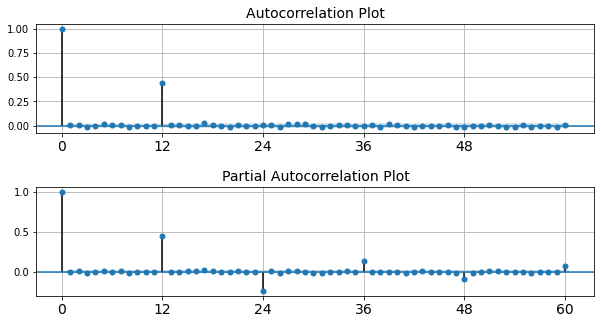

In [ ]:
plot_graphs_101_101_12(phi=0, Phi=0, theta=0, Theta=0.6)

These above graphs are for a pure seasonal $\text{MA}(1)_{12}$ model. The graphs tend to follow the pattern in ordinary MA(q) model that PACF values tend to tail off whereas ACF values cut off after lag q except that the significant values are at a distance of 12 (season in this case). Thus in case of a pure seasonal $\text{MA}(Q)_s$ model, the ACF values cut off after lag $Qs$ whereas the PACF values tail off at lags $ks, k = 1, 2, 3, ...$.


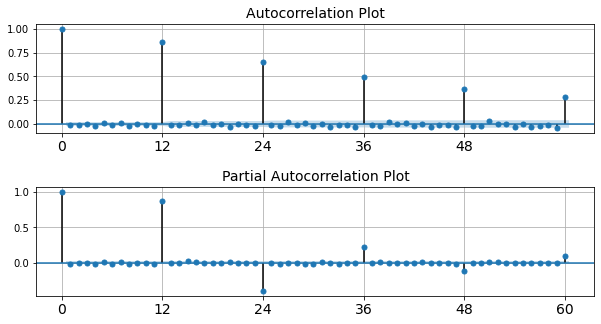

In [ ]:
plot_graphs_101_101_12(phi=0, Phi=0.75, theta=0, Theta=0.6)

The above graphs suggest that both PACF and ACF values for pure seasonal $\text{ARMA}(P, Q)_s$ tail off at lags $ks, k = 1, 2, 3, ...$.


#### Conclusion

The above three observations can be summarized in the following table. Note the AR, MA and ARMA models in this table are pure seasonal models.
>$\begin{array} 
\ &  & \textbf{AR}(P)_s &  & \textbf{MA}(Q)_s &  & \textbf{ARMA}(P, Q)_s 
\\
\textbf{ACF} & | & \text{tails off at lags}\ ks & | & \text{cuts off after lag}\ Qs & | & \text{tails off at lags}\ ks 
\\
\textbf{PACF} & | & \text{cuts off after lag}\ Ps & | & \text{tails off at lags}\ ks & | & \text{tails off at lags}\ ks 
\end{array}$




Let's see how mixture of seasonal and non-seasonal models affect the plots.


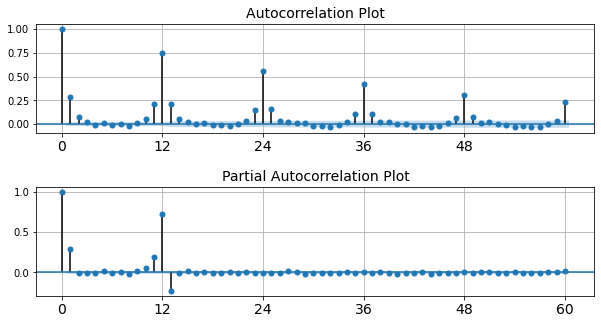

In [ ]:
plot_graphs_101_101_12(phi=0.3, Phi=0.75, theta=0, Theta=0)

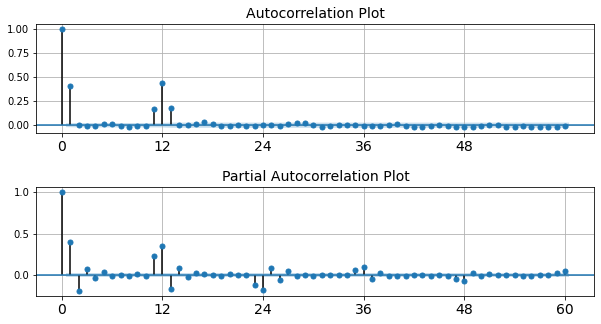

In [ ]:
plot_graphs_101_101_12(phi=0, Phi=0, theta=0.5, Theta=0.6)

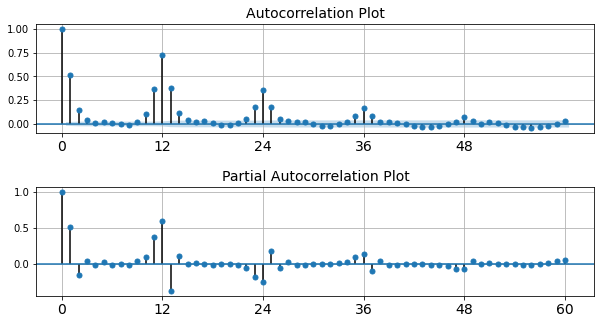

In [ ]:
plot_graphs_101_101_12(phi=0.3, Phi=0.5, theta=0.3, Theta=0.6)

On observing the above figure, the both ACF and PACF values tail off at seasonal lags as well as in between. This must be cumulative effect of seasonal and non-seasonal ARMA models.


## Fitting $\text{ARIMA}(p, d, q) \times (P, D, Q)_s$ model

**Steps:**

1. **Make Data Stationary**: Let the original data be denoted as $(X)$. Some transformations (like log transformation) can be required on the data to ensure variance stabilization. Let's denote the transformed data with $(f\_X)$. However, if no transformations are necessary, $f\_X = X$. If the transformed data $(f\_X)$ has a trend, we can remove it using non-seasonal differencing. Seasonality can still be present. We need to try seasonal differencing next for removing such seasonality. Let's say we get new stationary data is $(Xs)$ after $d$-order non-seasonal and $D$-order seasonal differencing.

2. **Estimate Orders**: Using ACF and PACF plots for the stationary data $(Xs)$, we can roughly estimate the model's orders. Note we don't need to have precise estimates at this point. We can estimate the range for these orders. Let the estimates for the ranges be denoted by $\hat{p}$, $\hat{q}$, $\hat{P}$, and $\hat{Q}$. 

3. **Fit and Select Model**: Fit models with order $(p, d, q) \times (P, D, Q)_s$  such that $p ∈ \hat{p}, q∈\hat{q}, P ∈ \hat{P}, Q∈\hat{Q}$ on the transformed data $(f\_X)$. Use the evaluation criterion to select the model.





Let's load a time series data named 'Air Passengers' and plot it. The data consists of the number of air passengers from the year 1949 to 1960 recorded for each month. Thus there are 12 * 12 = 144 data points in the data. We've dropped the information about year and months in the time series plot. 


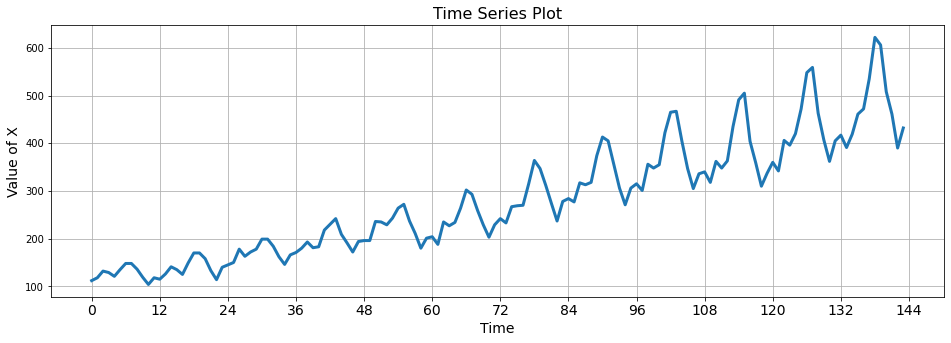

In [ ]:
df = pd.read_csv('https://storage.googleapis.com/codehub-data/1-lv2-11-1-AirPassengers.csv')
X = df['#Passengers'].values

plot_series(X, season=12)

The data seems to have an upward trend. Over a year, the number of flights can be high during vacation periods. We can observe a yearly seasonality present in the data. Thus we set the `season` variable to 12.


In [ ]:
season = 12

### Make Data Stationary

The variance seems to be increasing with time in the data. We need to stablize the variance of the data. A way can be to use logarithm scaling in the vertical axis. You can learn the steps involved in this chapter in more detail in our reading material named **Time Series Data Preprocessing**. Let's use log transformation now.


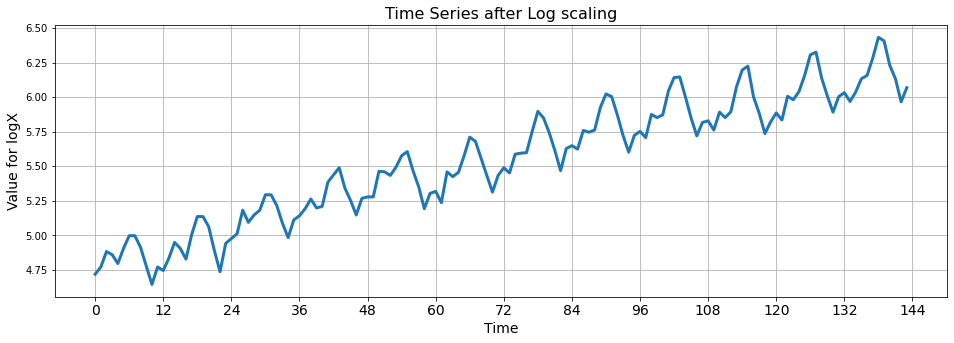

In [ ]:
log_X = np.log(X).copy()
plot_series(log_X, title='Time Series after Log scaling', y_label='Value for logX', season=season)

The variance in the data seems to be stablized now after log transformation. However, the data still has trend and seasonality. First, let's remove the trend in the data with differencing.


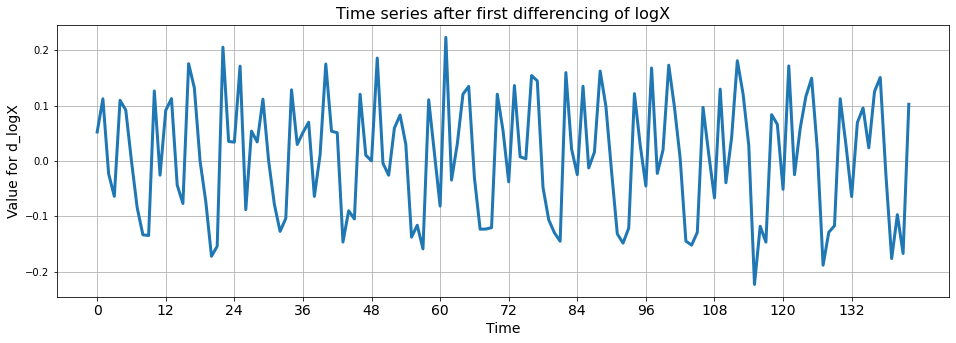

In [ ]:
d_log_X = tools.diff(log_X)

plot_series(
    d_log_X, 
    title='Time series after first differencing of logX', 
    y_label='Value for d_logX',
    season=season
)

The trend in the data has been removed but there's seasonlity present in the data. We can observe the repetation of pattern every 12 months. Hence, we try a step further by seasonal differencing with season 12. 


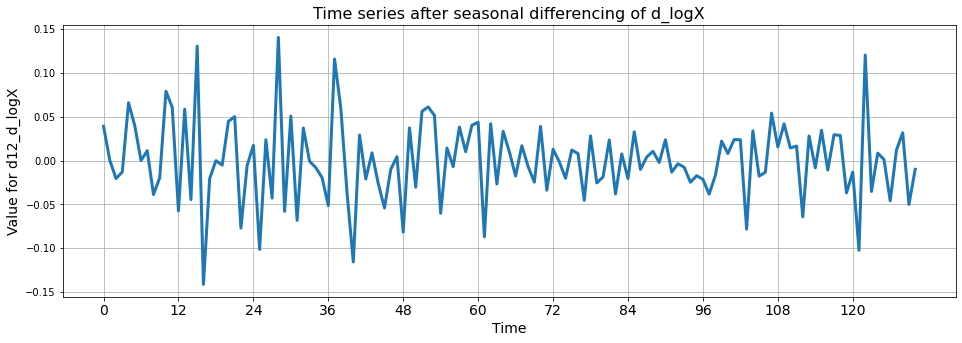

In [ ]:
d12_d_log_X = tools.diff(d_log_X, k_diff=0, k_seasonal_diff=1, seasonal_periods=season)

plot_series(
    d12_d_log_X, 
    title = 'Time series after seasonal differencing of d_logX', 
    y_label='Value for d12_d_logX',
    season=season
)

The data seems to be stationary now. Let's check using ADF test with p_value threshold of 0.05. 


In [ ]:
stattools.adfuller(d12_d_log_X)[1] #< 0.05

0.0002485912311384052

Since, the p-value returned is smaller than 0.05, we can proceed to estimate orders for the data. 


In [ ]:
d = 1
D = 1
X_stationary = d12_d_log_X

### Estimate Orders


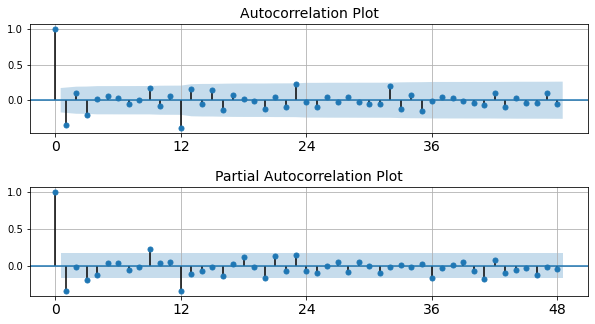

In [ ]:
plot_graphs(X_stationary, lags=48, season=season)


**Seasonal Orders $(\hat{P}, \hat{Q})$**
- We need to observe the autocorrelation and partial-autocorrelation values at seasonal lags (1s, 2s, 3s, ... , s=season). Since we have season of length 12 in the data, we'll observe the values at lags 12, 24, 36, ... . Both autocorrelation and partial-autocorrelation values are significantly large at lag 12. The values at seasonal lags can be suggestive of a pure SARMA(P=1, Q=1) component. However, we don't need to have precise estimation now. Let's make a search range of (0, 1) for P and (0, 1) for Q for now. 

**Non-seasonal Orders $(\hat{p}, \hat{q})$**
- For the non-seasonal orders, we look at the autocorrelation and partial-autocorrelation values in between the seasonal lags. Thus, we'll look at lags (1, 2, 3, ..., s - 1 where s=season). Both autocorrelation and partial-autocorrelation values are significantly large at lags 1 and 3 but small at lag 2. This can be suggestive of an ARMA(p=3, q=3) model. Let's make a search spaces of (0, 3) for both p and q. 



In [ ]:
# Seasonal orders
P_ = (0, 1)
Q_ = (0, 1)

# Non-seasonal orders
p_ = (0, 3)
q_ = (0, 3)

### Fit and Select Model

We'll use the Bayesian Information Criterion (BIC) as the evaluation metric. We can make brute force search over the ranges of orders to obtain the model with the minimum BIC value. For this, we can use `optimize.brute` from `scipy`. Know that it will take a while for the brute force search. 


In [ ]:
warnings.simplefilter('error', ConvergenceWarning)

# minimization function
def f(order, X):
    """ Minimization function
        It generates a SARIMA model with provided orders and fits on the time series.
        
    Args:
        order ((int, int, int, int)): Tuple of (p, q, P, Q)
        X (np.array): Time-series data
        
    Returns:
        (float or np.inf): BIC score for the model and np.inf in case of any exception
        
    """
    p, q, P, Q = order
    try:
        model = sm.tsa.SARIMAX(
            X, 
            order=(p, d, q), 
            seasonal_order=(P, D, Q, season)
        )
        model = model.fit(trend='nc', disp=-1)
    except:
        return np.inf
    return model.bic


# brute force search

order_grid = [slice(order[0], order[1] + 1 , 1) for order in (p_, q_, P_, Q_)]

min_order = optimize.brute(f, order_grid, args=(log_X,), finish=None, workers=4)
min_order = min_order.astype(int)

print('Order with minimum BIC : %s'%min_order)

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/statespace/sarimax.py:949: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/statespace/sarimax.py:961: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order with minimum BIC : [0 1 0 1]


In [ ]:
p, q, P, Q = min_order

### Predictions

Let's use the model with the lowest BIC and observe the forecast made by the model against the actual data.


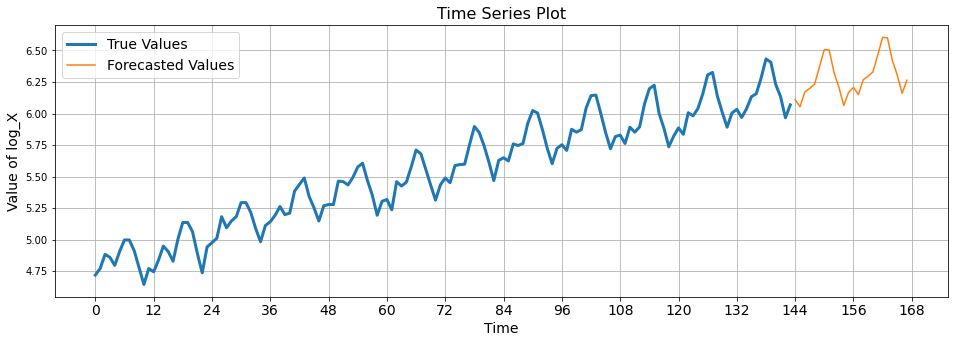

In [ ]:
model = sm.tsa.SARIMAX(
    log_X, 
    order=(p, d, q),
    seasonal_order=(P, D, Q, season)
).fit(trend='nc')

X_preds = model.forecast(24)

plot_series(
    log_X, X_preds, 
    y_label='Value of log_X',
    season=season, forecast=True
)

The above plot is for log-scaled data. We can map back to the previous scale with exponential function. This will result in the following plot.


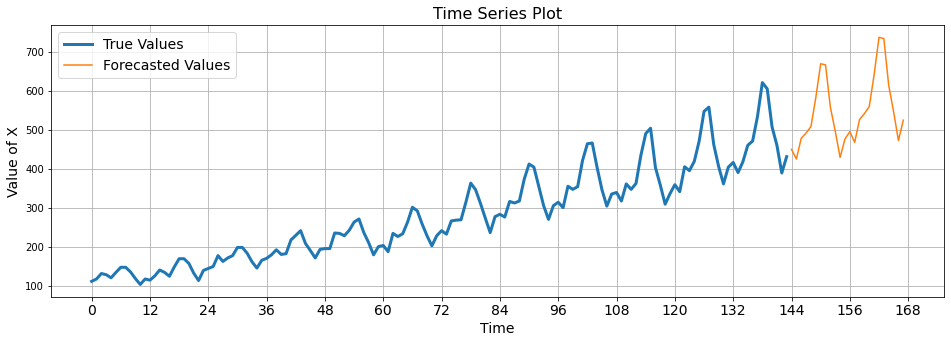

In [ ]:
plot_series(
    X, np.exp(X_preds), 
    season=season, forecast=True
)

## Key Takeaways

1. $X_t$ is said to be generated by a pure SARIMA$(P, D, Q)_s$ model if 
$
\Phi_P(B^s) \nabla_s ^D X_t = \Theta_Q(B^s) Z_t
$.

2. $X_t$ is said to be generated by an ARIMA$(p, d, q) \times (P, D, Q)_s$ model if
$
\Phi_P(B^s) \phi_p(B) \nabla_s ^D \nabla ^d X_t = \Theta_Q(B^s) \theta_q(B) Z_t
$.

3. For a pure seasonal $\text{AR}(P)_s$ model ACF plots tail off at lags $ks, k= 1,2,3,..$ and PACF plots cut off after lag $Ps$. Similarly, for a pure seasonal $\text{MA}(Q)_s$ model PACF plots tail off at lags $ks, k= 1,2,3,..$ and ACF plots cut off after lag $Qs$. Both ACF and PACF plots tail off at lags $ks, k = 1,2,3,...$ for pure seasonal $\text{ARMA}(P, Q)_s$ model.


## References

- Shumway R., Stoffer D. (2016) Time Series Analysis and Its Applications: With R Examples, 4th edition, Springer
    * Check definition 3.9 in page 148 for more information on SARIMA model.
